<a href="https://colab.research.google.com/github/DanielaRoque-max/8VO/blob/main/Copia_de_RL_Risk_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import math
from scipy import stats

##Data export

In [ ]:
import pandas as pd
#upload the data from our csv
url = 'https://raw.githubusercontent.com/lbabydany/Data_LifeExpectancyRegression/refs/heads/main/df'
df = pd.read_csv(url)

In [ ]:
df.head()

,Year,gov_expenditure,life_expectancy,inflation,tax,corruption,poverty_population,child mortality,trade
0,1980,1741.328162,64.2819,26.351652,12.144900,0.819,67300338,7.182316,22.434620
1,1981,2120.382594,64.7219,27.933764,11.851439,0.819,68892107,6.864985,22.117275
2,1982,2525.614080,65.2561,58.913420,12.044237,0.777,70433258,6.554602,24.134014
3,1983,2088.177592,65.7563,101.874940,14.390560,0.770,71971238,6.259071,27.096102
4,1984,1936.677045,66.2145,65.448810,13.963164,0.770,73506848,5.979309,25.672417


##EDA

Analyzed the variable 'Government Expenditure'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                43 non-null     int64  
 1   gov_expenditure     43 non-null     float64
 2   life_expectancy     43 non-null     float64
 3   inflation           43 non-null     float64
 4   tax                 43 non-null     float64
 5   corruption          43 non-null     float64
 6   poverty_population  43 non-null     int64  
 7   child mortality     43 non-null     float64
 8   trade               43 non-null     float64
dtypes: float64(7), int64(2)
memory usage: 3.2 KB


In [ ]:
def plot_LE_distribution(y, title="Distribution Goverment Expenditure", color="steelblue", figsize=(8, 5)):
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]  # tomar la primera columna

    plt.figure(figsize=figsize)
    sns.histplot(y, kde=True, color=color, bins=20, alpha=0.7, edgecolor='white')
    plt.title(title, fontsize=16, weight='bold', pad=20)
    plt.xlabel('Goverment Expenditure', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    sns.despine()
    plt.tight_layout()
    plt.show()

Define our variables

In [ ]:
y = df[['gov_expenditure']]
x = df[['life_expectancy', 'poverty_population', 'child mortality']]

### Descriptive Statistics for Dependent and Independent Variables

In [ ]:
print('Dependent Variable (Government Expenditure) Descriptive Statistics:')
display(y.describe())

print('\nIndependent Variables Descriptive Statistics:')
display(x.describe())

Dependent Variable (Government Expenditure) Descriptive Statistics:


,gov_expenditure
count,43.000000
mean,2875.350853
std,1073.439920
min,1274.706942
25%,2105.131447
50%,2499.697474
75%,4106.723292
max,4639.851131



Independent Variables Descriptive Statistics:


,life_expectancy,poverty_population,child mortality
count,43.000000,4.300000e+01,43.000000
mean,71.189205,9.950795e+07,3.252971
std,3.110561,1.885869e+07,1.731694
min,64.281900,6.730034e+07,1.287386
25%,69.201250,8.362537e+07,1.820815
50%,72.203400,1.000991e+08,2.683880
75%,73.770600,1.160309e+08,4.425135
max,74.530200,1.286131e+08,7.182316


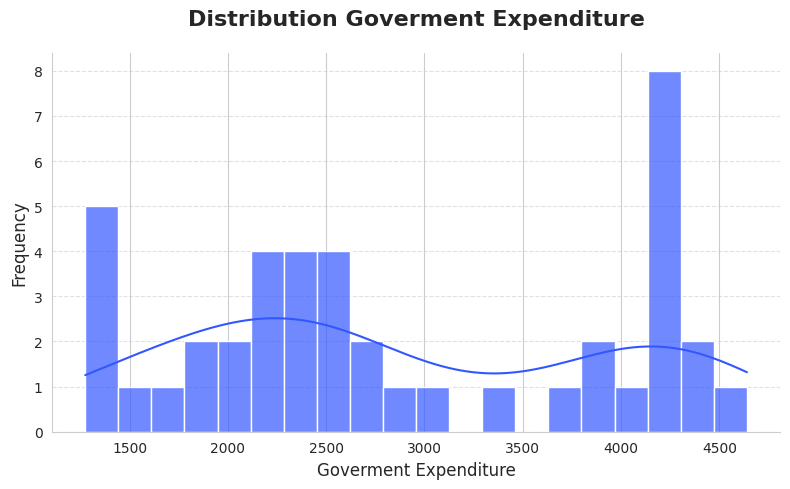

In [ ]:
# apply the function
plot_LE_distribution(y, color="#3357FF")

Evualate the X's against the Y's

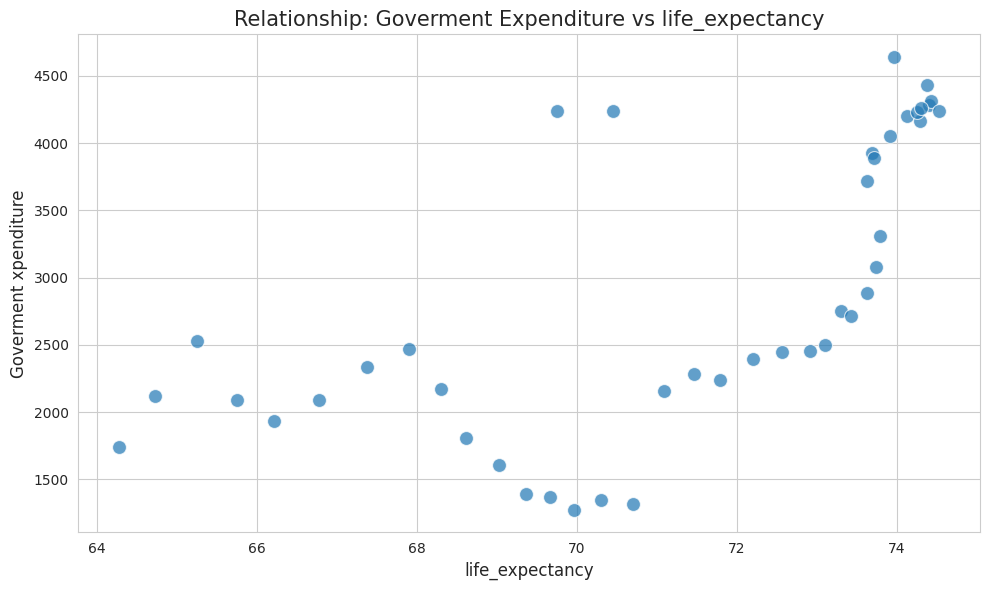

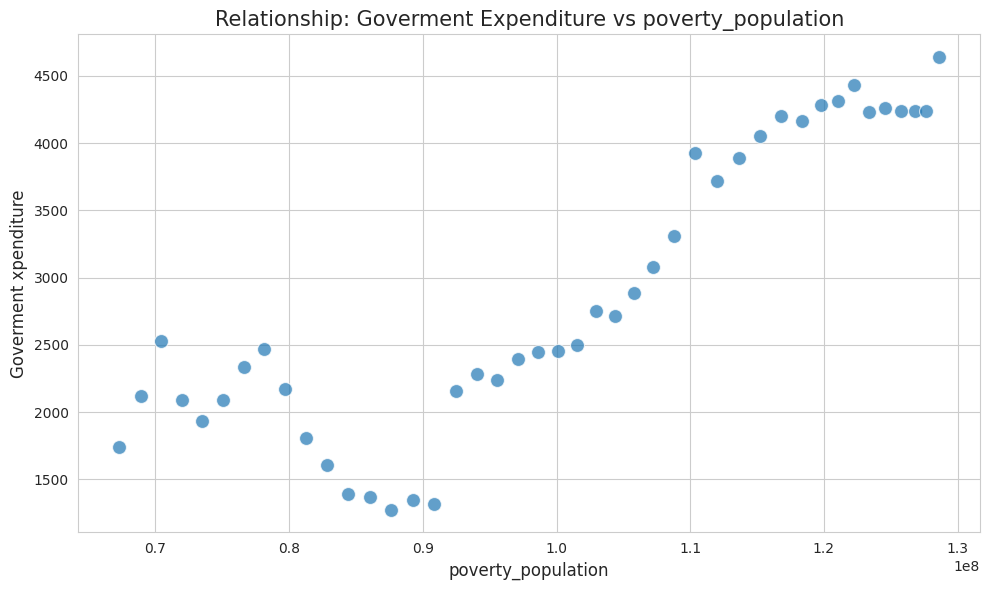

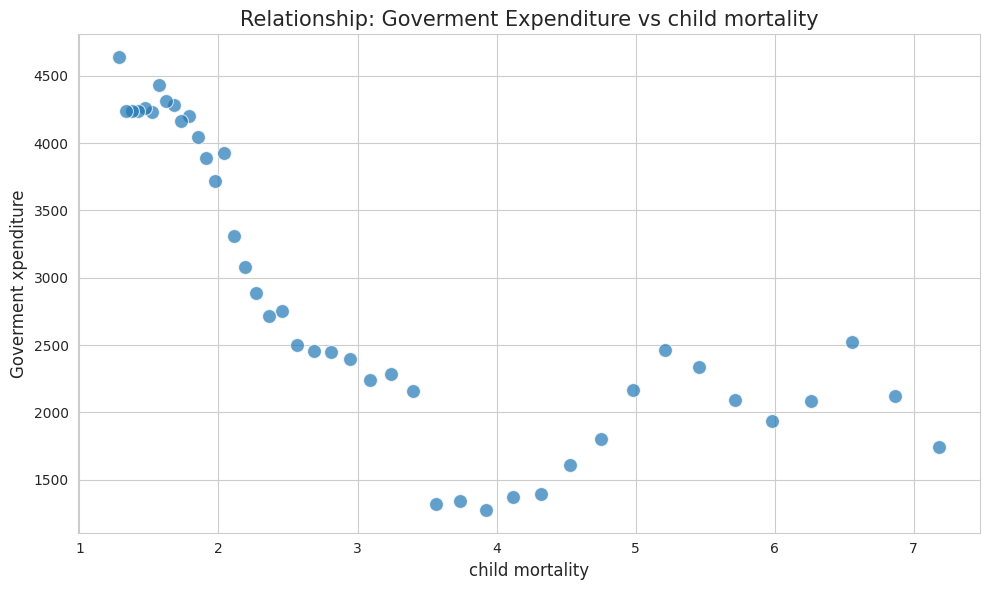

In [ ]:
# Analysis of the relationship between variable Y and variables X
variables_x = ['life_expectancy', 'poverty_population', 'child mortality']

sns.set_style("whitegrid")

for var in variables_x:
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=var,
        y='gov_expenditure',
        s=100,
        alpha=0.7
    )

    plt.title(f'Relationship: Goverment Expenditure vs {var}', fontsize=15)
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Goverment xpenditure', fontsize=12)

    plt.tight_layout()
    plt.show()

##Lineal Regression

Analysis of the correlation matrix

Correlation Matrix:
                    life_expectancy  poverty_population  child mortality
life_expectancy            1.000000            0.869354        -0.943329
poverty_population         0.869354            1.000000        -0.965660
child mortality           -0.943329           -0.965660         1.000000


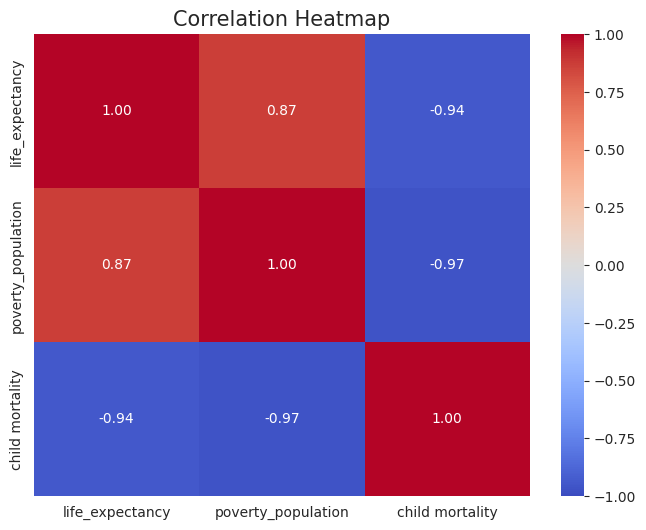

In [ ]:
# 1. Correlation matrix
corr_matrix = x.corr()
print("Correlation Matrix:")
print(corr_matrix)

# 2. Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,       # Show correlation values
            cmap='coolwarm',  # Blue = negative, Red = positive
            fmt=".2f",        # Two decimals
            vmin=-1, vmax=1)  # Fixed correlation range

plt.title('Correlation Heatmap', fontsize=15)
plt.show()

In [ ]:
def prepare_data(X, y):
    """
    Limpia X e y alineándolos y borrando nulos/infinitos
    """
    X = X.copy()
    y = y.copy()

    # Unir para borrar filas donde falte CUALQUIER dato
    data = pd.concat([X, y], axis=1)
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(inplace=True)

    # Separar de nuevo (Asumiendo que y es la última columna)
    y_clean = data.iloc[:, -1]
    X_clean = data.iloc[:, :-1]

    return X_clean, y_clean

In [ ]:
import statsmodels.api as sm

def run_linear_regression(X, y, league_name="Liga"):
    # Preparar datos limpios
    X_clean, y_clean = prepare_data(X, y)

    if X_clean.empty:
        raise ValueError(f"No hay datos válidos para {league_name}")

    # Agregar constante
    X_with_const = sm.add_constant(X_clean)

    # Ajustar modelo
    model = sm.OLS(y_clean, X_with_const).fit()

    print(f"\n{'='*70}")
    print(f"REGRESIÓN LINEAL - {league_name}")
    print(f"{'='*70}")
    print(model.summary())

    return model

In [ ]:
model = run_linear_regression(x, y, "LE")


REGRESIÓN LINEAL - LE
                            OLS Regression Results                            
Dep. Variable:        gov_expenditure   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     131.3
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.02e-20
Time:                        19:08:31   Log-Likelihood:                -308.85
No. Observations:                  43   AIC:                             625.7
Df Residuals:                      39   BIC:                             632.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const        

##Assumpments

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_residuals_fixed(x_data, y_data):
    # Align indices
    y_data = y_data.loc[x_data.index]

    # Fit the model directly with all predictors (no filtering)
    model = sm.OLS(y_data, sm.add_constant(x_data)).fit()

    residuals = model.resid
    predictions = model.fittedvalues

    # Normality test
    stat, p_value_shapiro = stats.shapiro(residuals)
    normality_str = "Normal" if p_value_shapiro > 0.05 else "Not Normal"

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle(
        f"Residual Analysis (R²: {model.rsquared:.2f}, Normality: {normality_str})",
        fontsize=18, weight='bold', y=1.05
    )

    sns.histplot(residuals, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title("Residual Distribution")
    axes[0].set_xlabel("Residuals")

    sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
    axes[1].set_title("Q-Q Plot")

    sns.scatterplot(x=predictions, y=residuals, ax=axes[2], alpha=0.6, color='purple')
    axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[2].set_title("Homoscedasticity")
    axes[2].set_xlabel("Predicted Values")
    axes[2].set_ylabel("Residuals")

    plt.tight_layout()
    plt.show()

    return model

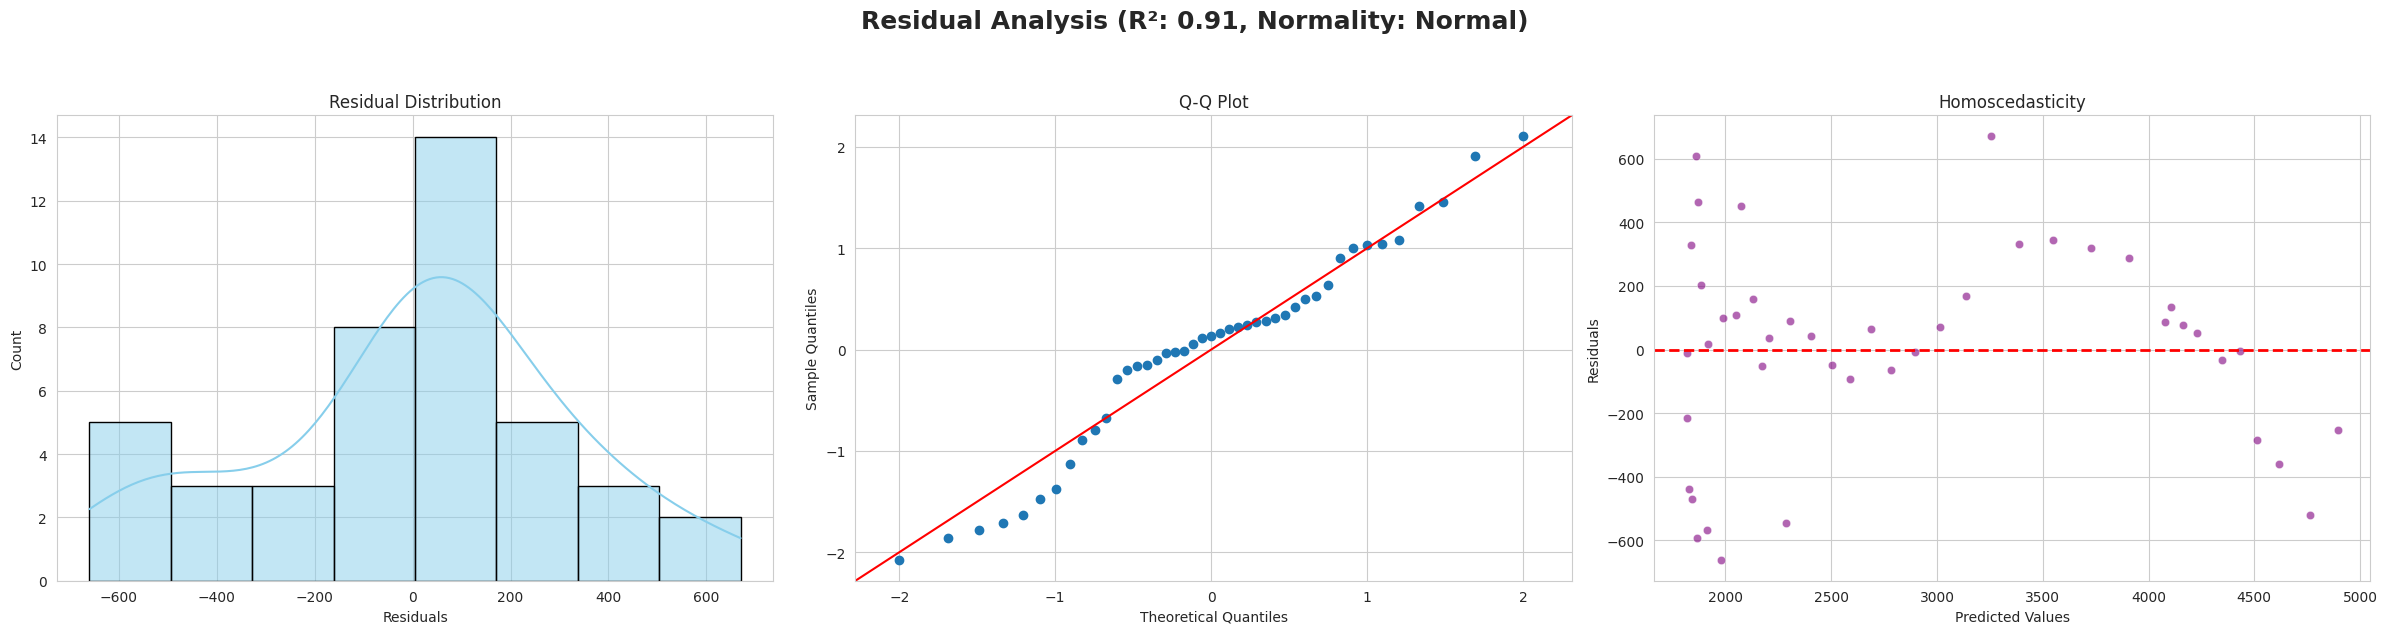

                            OLS Regression Results                            
Dep. Variable:        gov_expenditure   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     131.3
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.02e-20
Time:                        19:08:32   Log-Likelihood:                -308.85
No. Observations:                  43   AIC:                             625.7
Df Residuals:                      39   BIC:                             632.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.739e+04   5341

In [ ]:
model = analyze_residuals_fixed(x, y)
print(model.summary())

Analysis of normality on residuals

In [ ]:

residuals = model.resid
stat, p_value_shapiro = stats.shapiro(residuals)

print(f"Shapiro-Wilk Test for Normality of Residuals:")
print(f"  Test Statistic: {stat:.4f}")
print(f"  P-value: {p_value_shapiro:.4f}")

if p_value_shapiro > 0.05:
    print(f"  Conclusion: Residuals appear to be normally distributed (p > 0.05).")
else:
    print(f"  Conclusion: Residuals do not appear to be normally distributed (p <= 0.05).")

Shapiro-Wilk Test for Normality of Residuals:
  Test Statistic: 0.9610
  P-value: 0.1506
  Conclusion: Residuals appear to be normally distributed (p > 0.05).


Analysis of homoscedasticity

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.api import het_breuschpagan

residuals = model.resid

X_with_const = sm.add_constant(x)


lm_statistic, lm_p_value, f_statistic, f_p_value = het_breuschpagan(residuals, X_with_const)

print(f"\nBreusch-Pagan Test for Homoscedasticity:")
print(f"  LM Statistic: {lm_statistic:.4f}")
print(f"  LM P-value: {lm_p_value:.4f}")
print(f"  F-Statistic: {f_statistic:.4f}")
print(f"  F P-value: {f_p_value:.4f}")

alpha = 0.05
if lm_p_value < alpha:
    print(f"  Conclusion: We reject the null hypothesis. There is evidence of heteroscedasticity (p < {alpha}).")
else:
    print(f"  Conclusion: We fail to reject the null hypothesis. There is no significant evidence of heteroscedasticity (p >= {alpha}).")


Breusch-Pagan Test for Homoscedasticity:
  LM Statistic: 2.1800
  LM P-value: 0.5359
  F-Statistic: 0.6943
  F P-value: 0.5611
  Conclusion: We fail to reject the null hypothesis. There is no significant evidence of heteroscedasticity (p >= 0.05).


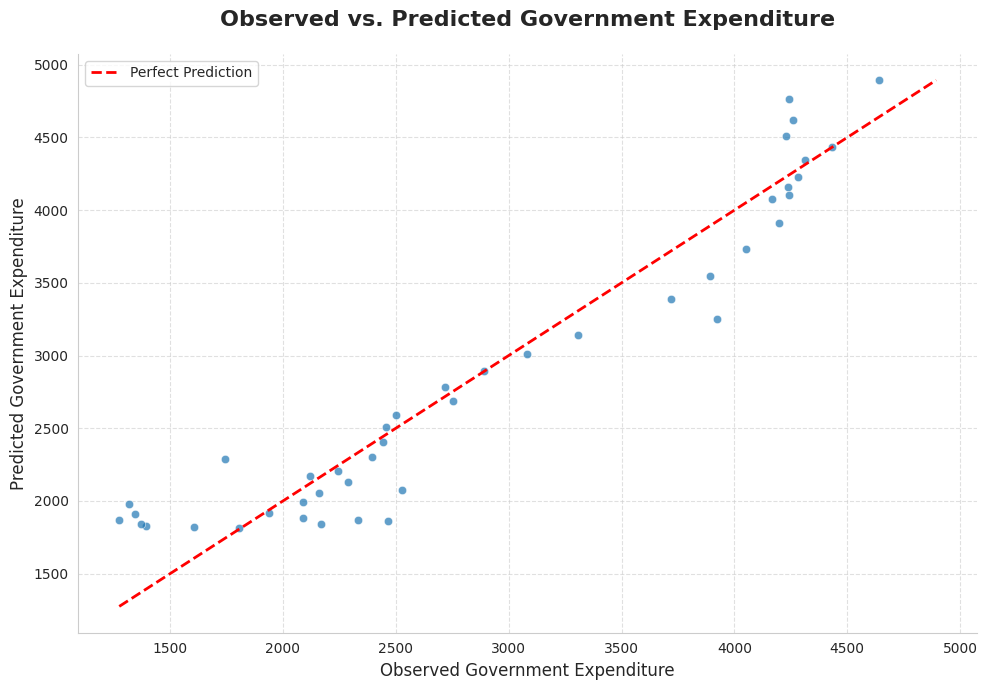

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted values and observed values
predictions = model.fittedvalues
observed = y.iloc[:, 0]  # Assuming y is a DataFrame with one column

plt.figure(figsize=(10, 7))
sns.scatterplot(x=observed, y=predictions, alpha=0.7)

# Add a line for perfect prediction (y = x)
max_val = max(observed.max(), predictions.max())
min_val = min(observed.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Observed vs. Predicted Government Expenditure', fontsize=16, weight='bold', pad=20)
plt.xlabel('Observed Government Expenditure', fontsize=12)
plt.ylabel('Predicted Government Expenditure', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()